# **Market Risk Structure & Stability Analysis Using Statistical and Linear Algebra Methods**

Dataset:
S&P 500 Stock Prices Dataset

---

# 🧠 Problem Statement

Financial markets contain large numbers of correlated assets whose behavior is governed by underlying economic forces.

Understanding these relationships is essential for:

* Risk management
* Portfolio construction
* Factor modeling
* Market anomaly detection

This project investigates financial markets through:

### Statistical Analysis

* Random variables
* Distribution properties
* Heavy-tailed behavior
* Confidence intervals
* Hypothesis testing

### Linear Algebra

* Vectors and matrices
* Covariance matrices
* Eigenvalue analysis

### Machine Learning Concepts

* PCA for factor discovery
* Feature stability over time
* Removal of noisy features

The goal is to determine:

* Whether financial returns follow classical statistical assumptions
* How market risk structures evolve
* Which features are stable enough for modeling

---

# 1️⃣ Import Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import ttest_ind

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2️⃣ Load Dataset

In [4]:
path = '/content/drive/MyDrive/Data/S&P_10/'

Tickers = ['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOG', 'IBM', 'MSFT', 'NFLX', 'SBUX', 'TSLA']

In [5]:
files = []

for t in Tickers:
  df = pd.read_csv(f'{path}{t}.csv')
  df['Ticker'] = t
  files.append(df)

data = pd.concat(files, ignore_index=True)

In [6]:
# Clean Data
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data = data.dropna(subset=['Date'])
data = data.sort_values(['Ticker', 'Date']).reset_index(drop=True)

In [9]:
print('\nPanel dataset')
print(data.head())


Panel dataset
  Ticker       Date      Open      High       Low     Close  Adj Close  \
0   AAPL 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.099584   
1   AAPL 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094388   
2   AAPL 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087461   
3   AAPL 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089625   
4   AAPL 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092224   

      Volume  
0  469033600  
1  175884800  
2  105728000  
3   86441600  
4   73449600  



Expected dataset structure

| Date       | Symbol | Close |
| ---------- | ------ | ----- |
| 2020-01-01 | AAPL   | 300   |
| 2020-01-01 | MSFT   | 160   |

---

# 3️⃣ Convert Dataset Into Matrix Format

To apply linear algebra methods we need matrix form.

In [15]:
#Price Matrix
prices = data.pivot(
    index='Date',
    columns='Ticker',
    values='Close'
).sort_index()

In [11]:
prices.isnull().sum()

,0
Ticker,
AAPL,4753
AMD,4565
AMZN,8905
CSCO,7074
GOOG,10731
IBM,0
MSFT,6079
NFLX,10167
SBUX,7670


In [12]:
prices.dropna(inplace=True)

In [13]:
prices.head()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Date,,,,,,,,,,
2010-06-29,9.148929,7.48,5.4305,21.620001,11.314092,119.588913,23.309999,16.082857,12.505,1.592667
2010-06-30,8.983214,7.32,5.4630,21.309999,11.082211,118.049713,23.010000,15.521429,12.150,1.588667
2010-07-01,8.874286,7.39,5.5480,21.260000,10.946221,117.179733,23.160000,15.665714,12.330,1.464000
2010-07-02,8.819286,7.17,5.4570,21.129999,10.872995,116.500954,23.270000,15.297143,12.175,1.280000
2010-07-06,8.879643,7.04,5.5030,21.340000,10.861040,118.030594,23.820000,15.324286,11.805,1.074000


In [14]:
prices.describe()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
count,3297.000000,3297.000000,3297.000000,3297.000000,3297.000000,3297.000000,3297.000000,3297.000000,3297.000000,3297.000000
mean,58.018790,30.840558,63.104811,34.541134,52.983386,148.728423,111.358338,202.635912,58.958808,65.119803
std,52.086513,37.873051,53.901327,12.896380,37.468229,23.656941,95.587230,178.514531,29.236401,98.306230
min,8.568929,1.620000,5.430500,13.730000,10.861040,90.602295,23.010000,7.685714,11.410000,1.053333
25%,20.517857,4.020000,15.018000,23.010000,22.644623,131.339996,34.990002,44.857143,35.775002,9.862667
50%,32.547501,10.040000,41.436001,31.270000,40.230499,142.970001,63.189999,132.889999,56.799999,16.661333
75%,79.239998,52.730000,97.250000,46.279999,70.991501,166.835571,181.399994,344.500000,83.180000,53.250000
max,196.449997,161.910004,186.570496,63.959999,150.709000,206.309753,359.489990,691.690002,126.059998,409.970001


Shape:

---

# 4️⃣ Random Variables in Finance

Daily stock returns are treated as **random variables**.

Return formula

$$
R_t = \ln \left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are used because they are **additive over time**.

---

### Calculate Log Returns

In [16]:
# Returns

returns = prices.pct_change().dropna()
prices = prices.dropna(how='all')

In [19]:
returns.head()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Date,,,,,,,,,,
2010-06-30,-0.018113,-0.021390,0.005985,-0.014339,-0.020495,-0.012871,-0.012870,-0.034908,-0.028389,-0.002511
2010-07-01,-0.012126,0.009563,0.015559,-0.002346,-0.012271,-0.007370,0.006519,0.009296,0.014815,-0.078473
2010-07-02,-0.006198,-0.029770,-0.016402,-0.006115,-0.006690,-0.005793,0.004750,-0.023527,-0.012571,-0.125683
2010-07-06,0.006844,-0.018131,0.008430,0.009939,-0.001100,0.013130,0.023636,0.001774,-0.030390,-0.160937
2010-07-07,0.040381,0.049716,0.030620,0.053421,0.032403,0.028673,0.020151,0.104596,0.033460,-0.019243


In [17]:
log_returns = np.log(prices / prices.shift(1)).dropna()

In [20]:
log_returns.head()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Date,,,,,,,,,,
2010-06-30,-0.018279,-0.021622,0.005967,-0.014442,-0.020708,-0.012954,-0.012954,-0.035532,-0.028799,-0.002515
2010-07-01,-0.012200,0.009517,0.015439,-0.002349,-0.012347,-0.007397,0.006498,0.009253,0.014706,-0.081723
2010-07-02,-0.006217,-0.030222,-0.016538,-0.006134,-0.006712,-0.005809,0.004738,-0.023808,-0.012651,-0.134312
2010-07-06,0.006820,-0.018298,0.008394,0.009889,-0.001100,0.013044,0.023361,0.001773,-0.030861,-0.175470
2010-07-07,0.039587,0.048520,0.030160,0.052043,0.031889,0.028270,0.019951,0.099480,0.032913,-0.019431



Each column now represents a **random variable describing asset return**.

---

# 5️⃣ Distribution Analysis of Returns

Financial returns often deviate from normality.

### Histogram

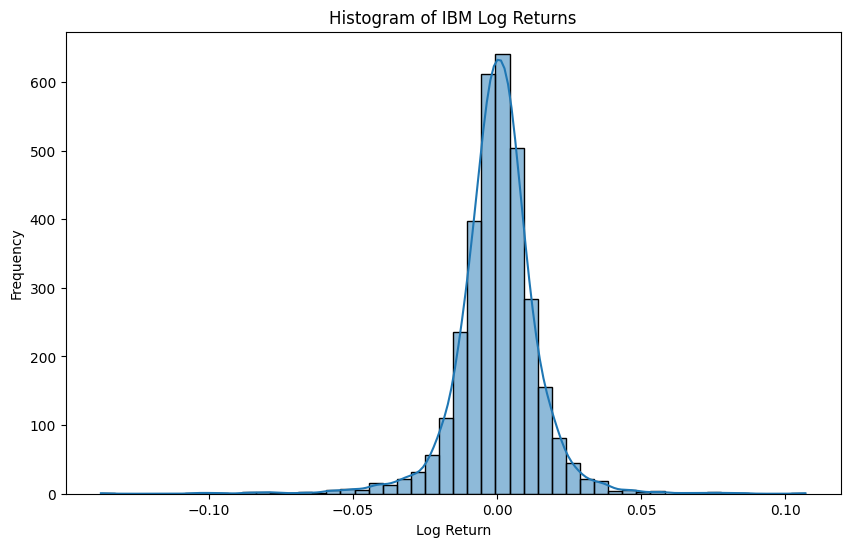

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(log_returns['IBM'], bins=50, kde=True)
plt.title('Histogram of IBM Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

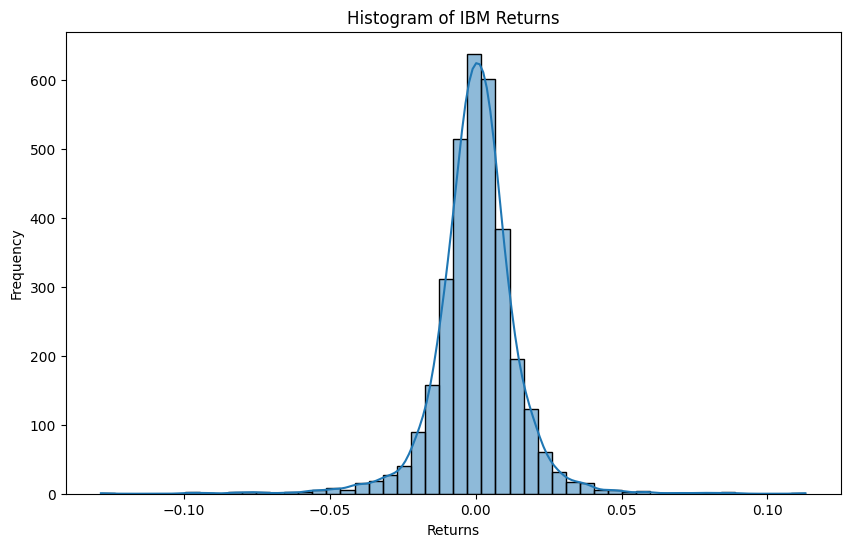

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(returns['IBM'], bins=50, kde=True)
plt.title('Histogram of IBM Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

---

# 6️⃣ Normality Testing

We formally test if returns follow a normal distribution.

### Shapiro-Wilk Test

In [23]:
stats.shapiro(log_returns['IBM'].sample(1000))


ShapiroResult(statistic=np.float64(0.8639750220806507), pvalue=np.float64(1.4514746727139568e-28))

If

```
p < 0.05
```

Reject normality assumption.

---

# 7️⃣ Heavy-Tailed Behavior

Calculate kurtosis.

In [24]:
kurt = log_returns['IBM'].kurtosis()

print('Kurtosis', kurt)

Kurtosis 10.196161721168512


Interpretation

```
Kurtosis > 3 → Heavy tails
```

Meaning extreme events occur more often than predicted by normal models.

This is common in financial markets.

---

# 8️⃣ Descriptive Statistics

Compute moments of distribution.

In [25]:
descriptive_stats = pd.DataFrame(
    {
    'Mean': log_returns.mean(),
    'Variance': log_returns.std(),
    'skewness': log_returns.skew(),
    'kurtosis': log_returns.kurtosis()

   }
)

descriptive_stats.head()

,Mean,Variance,skewness,kurtosis
Ticker,,,,
AAPL,0.000922,0.017837,-0.259964,5.605658
AMD,0.000827,0.035416,0.289796,9.935219
AMZN,0.000962,0.020733,0.032190,6.343883
CSCO,0.000273,0.016798,-0.866983,16.837375
GOOG,0.000739,0.017161,0.237851,7.691405




Interpretation:

Mean → expected return
Variance → volatility
Skewness → asymmetry
Kurtosis → tail risk

---

# 9️⃣ Confidence Interval for Mean Return

We estimate a range where true mean return lies.

In [26]:
confidence_interval = 0.95
sample = log_returns['IBM']
sem = stats.sem(sample) #sem -> standard error of the mean
# sem  = log_return.std()/(len(log_return)**(1/2))


ci = stats.t.interval(confidence_interval, len(sample)-1, loc=np.mean(sample), scale=sem)

print(f'95% of CI :  {ci}')

95% of CI :  (np.float64(-0.0004286986740387468), np.float64(0.0005438101629549614))





Interpretation

95% confidence that the true mean return lies inside the interval.

---

# 🔟 Hypothesis Testing

Test if two stocks have equal mean returns.

### Hypothesis

H0:

```
Mean_AAPL = Mean_MSFT
```

H1:

```
Means are different
```

### Test

In [27]:
stats.ttest_ind(log_returns['AAPL'], log_returns['IBM'])

TtestResult(statistic=np.float64(2.175524411180611), pvalue=np.float64(0.029626261805034637), df=np.float64(6590.0))

If

```
p < 0.05
```

Reject null hypothesis.

---

# 1️⃣1️⃣ Market Data as Vectors

Daily market returns can be written as a vector.

Example

$$
r =
\begin{bmatrix}
r_{AAPL} \
r_{MSFT} \
r_{GOOG}
\end{bmatrix}
$$

In Python

In [28]:
log_returns.iloc[0].values

array([-0.01827902, -0.02162244,  0.00596684, -0.01444243, -0.02070783,
       -0.0129543 , -0.01295352, -0.03553234, -0.02879944, -0.00251464])

In [29]:
#Matrix repersentation
log_returns.iloc[0:].values

array([[-0.01827902, -0.02162244,  0.00596684, ..., -0.03553234,
        -0.02879944, -0.00251464],
       [-0.01219992,  0.00951737,  0.01543942, ...,  0.00925293,
         0.01470617, -0.08172292],
       [-0.00621689, -0.03022205, -0.01653833, ..., -0.02380844,
        -0.01265063, -0.13431235],
       ...,
       [-0.00428505,  0.02758793, -0.01499814, ..., -0.00079765,
        -0.00305673, -0.02406922],
       [-0.01561122, -0.07273529, -0.0267811 , ..., -0.0205461 ,
         0.008555  , -0.02702135],
       [-0.00659036,  0.04208324,  0.00776944, ...,  0.02021709,
         0.00233748,  0.01437809]])

---

# 1️⃣2️⃣ Matrix Representation

Full dataset forms a matrix.

$$
X =
\begin{bmatrix}
r_{1,1} & r_{1,2} & r_{1,3} \
r_{2,1} & r_{2,2} & r_{2,3}
\end{bmatrix}
$$

Where

```
Rows = time
Columns = assets
```

---

# 1️⃣3️⃣ Covariance Matrix

Covariance describes relationships between assets.

$$
Cov(X,Y) = E[(X-\mu_X)(Y-\mu_Y)]
$$

Compute covariance matrix.

In [30]:
cov_matrix_log_returns = log_returns.cov()

cov_matrix_log_returns

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Ticker,,,,,,,,,,
AAPL,0.000318,0.000248,0.000181,0.000139,0.000172,0.000102,0.000174,0.000174,0.000132,0.000232
AMD,0.000248,0.001254,0.000274,0.000200,0.000219,0.000152,0.000247,0.000324,0.000191,0.000401
AMZN,0.000181,0.000274,0.000430,0.000132,0.000215,0.000093,0.000194,0.000293,0.000147,0.000266
CSCO,0.000139,0.000200,0.000132,0.000282,0.000131,0.000121,0.000149,0.000128,0.000125,0.000154
GOOG,0.000172,0.000219,0.000215,0.000131,0.000295,0.000100,0.000184,0.000205,0.000138,0.000209
IBM,0.000102,0.000152,0.000093,0.000121,0.000100,0.000203,0.000109,0.000073,0.000101,0.000111
MSFT,0.000174,0.000247,0.000194,0.000149,0.000184,0.000109,0.000272,0.000183,0.000138,0.000211
NFLX,0.000174,0.000324,0.000293,0.000128,0.000205,0.000073,0.000183,0.001054,0.000148,0.000335
SBUX,0.000132,0.000191,0.000147,0.000125,0.000138,0.000101,0.000138,0.000148,0.000281,0.000184


---

### Visualize Covariance Structure

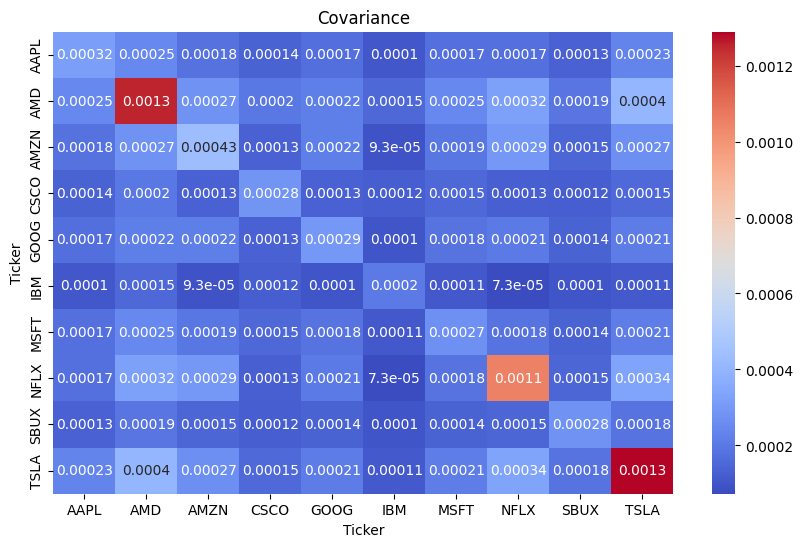

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(cov_matrix_log_returns, annot=True, cmap='coolwarm')
plt.title('Covariance')
plt.show()

Interpretation

Large covariance → assets move together.

---

# 1️⃣4️⃣ Eigenvalue Decomposition

Covariance matrix contains hidden structure.

Eigen decomposition:

$$
\Sigma v = \lambda v
$$

Where

λ → eigenvalues
v → eigenvectors

---

### Compute Eigenvalues

In [32]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix_log_returns)

eigenvalues, eigenvectors

(array([2.54582522e-03, 8.79121336e-04, 8.18070091e-04, 5.49623545e-04,
        2.33738968e-04, 1.66762520e-04, 1.54936509e-04, 9.29894466e-05,
        1.24693186e-04, 1.12594847e-04]),
 array([[ 0.22754143,  0.03832823, -0.00535391,  0.31703838, -0.03431452,
          0.67284303, -0.42352332, -0.08300847,  0.44551289,  0.0870314 ],
        [ 0.51370976,  0.62898342, -0.42370167, -0.39906684,  0.02159157,
         -0.01954248, -0.00470044, -0.0239923 , -0.01370557, -0.00842696],
        [ 0.27930299,  0.03313716,  0.13506785,  0.302411  ,  0.7346862 ,
         -0.25330883,  0.28819652,  0.0171363 ,  0.33806494,  0.09812269],
        [ 0.17823522,  0.07069327, -0.00830659,  0.33010297, -0.46599875,
          0.01523302,  0.58598459, -0.18617733,  0.22086963, -0.45824391],
        [ 0.22422156,  0.03708672,  0.06870354,  0.33850229,  0.18252256,
          0.10243893, -0.11257549, -0.53983998, -0.68610013, -0.10199627],
        [ 0.1280615 ,  0.05789885, -0.03251271,  0.25992722, -0.34712



Interpretation

Large eigenvalues represent **dominant market risk factors**.

---

# 1️⃣5️⃣ PCA Factor Extraction

Principal Component Analysis transforms correlated variables into independent factors.

---

### Standardize Data

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(log_returns)

X_scaled

array([[-1.07662921, -0.63396387,  0.2414534 , ..., -1.12554297,
        -1.75532497, -0.11304249],
       [-0.73577267,  0.24542916,  0.69841112, ...,  0.25415918,
         0.83888164, -2.31955475],
       [-0.40030291, -0.87681815, -0.84419705, ..., -0.7643642 ,
        -0.79238368, -3.78454347],
       ...,
       [-0.29198374,  0.75574472, -0.76989801, ..., -0.05546965,
        -0.22030658, -0.71349058],
       [-0.9270453 , -2.07739858, -1.33830866, ..., -0.66386121,
         0.47209167, -0.79572829],
       [-0.4212435 ,  1.16509458,  0.32841104, ...,  0.59193271,
         0.10134581,  0.35753967]])

---

### Fit PCA


In [34]:
pca = PCA()

pca.fit(X_scaled)

PCA()

---

### Explained Variance

In [35]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.46468926, 0.10243664, 0.07629189, 0.06840752, 0.06395468,
       0.05664858, 0.04944693, 0.04649118, 0.03863323, 0.03300008])

Observation

Often:

```
First component explains 30–50% of market variance
```

This represents **overall market movement**.

---

# 1️⃣6️⃣ Market Factor Visualization

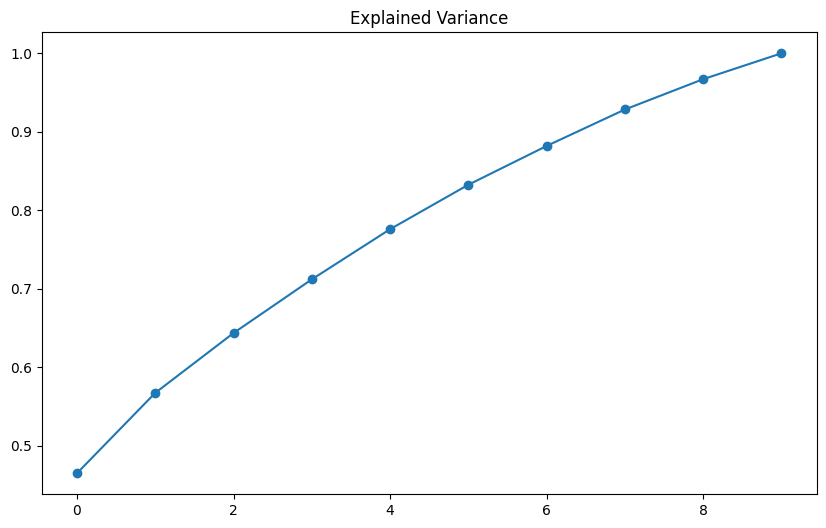

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Explained Variance')
plt.show()


---

# 1️⃣7️⃣ Feature Stability Over Time

Financial relationships change over time.

We analyze stability using **rolling windows**.

---

### Rolling Covariance

In [37]:
log_returns.rolling(20).cov().dropna()

Ticker                 AAPL       AMD      AMZN      CSCO      GOOG       IBM  \
Date       Ticker                                                               
2010-07-28 AAPL    0.000245  0.000159  0.000006  0.000156  0.000143  0.000039   
           AMD     0.000159  0.000499  0.000173  0.000239  0.000265  0.000129   
           AMZN    0.000006  0.000173  0.000306  0.000238  0.000262  0.000147   
           CSCO    0.000156  0.000239  0.000238  0.000433  0.000373  0.000180   
           GOOG    0.000143  0.000265  0.000262  0.000373  0.000556  0.000165   
...                     ...       ...       ...       ...       ...       ...   
2023-08-03 IBM    -0.000018 -0.000094 -0.000047  0.000031 -0.000026  0.000049   
           MSFT    0.000071  0.000278  0.000158 -0.000002  0.000067 -0.000035   
           NFLX    0.000113  0.000450  0.000288  0.000054  0.000143 -0.000077   
           SBUX   -0.000019  0.000020  0.000025  0.000019 -0.000054 -0.000016   
           TSLA    0.000172  0.000457  0.000363 -0.000019  0.000341 -0.000100   

Ticker                 MSFT      NFLX      SBUX      TSLA  
Date       Ticker                                          
2010-07-28 AAPL    0.000061  0.000162  0.000059 -0.000207  
           AMD     0.000148  0.000230  0.000268  0.000280  
           AMZN    0.000157  0.000088  0.000205  0.000203  
           CSCO    0.000221  0.000166  0.000246  0.000030  
           GOOG    0.000216  0.000320  0.000315  0.000067  
...                     ...       ...       ...       ...  
2023-08-03 IBM    -0.000035 -0.000077 -0.000016 -0.000100  
           MSFT    0.000350  0.000334  0.000012  0.000324  
           NFLX    0.000334  0.000817  0.000057  0.000707  
           SBUX    0.000012  0.000057  0.000104  0.000037  
           TSLA    0.000324  0.000707  0.000037  0.000962  

[32770 rows x 10 columns]

---

### Rolling Correlation


In [38]:
rolling_corr = log_returns.rolling(20).corr().dropna()
rolling_corr

Ticker                 AAPL       AMD      AMZN      CSCO      GOOG       IBM  \
Date       Ticker                                                               
2010-07-28 AAPL    1.000000  0.455896  0.020570  0.477148  0.387106  0.191277   
           AMD     0.455896  1.000000  0.441958  0.514138  0.503395  0.444165   
           AMZN    0.020570  0.441958  1.000000  0.653763  0.635859  0.650058   
           CSCO    0.477148  0.514138  0.653763  1.000000  0.760670  0.666966   
           GOOG    0.387106  0.503395  0.635859  0.760670  1.000000  0.539938   
...                     ...       ...       ...       ...       ...       ...   
2023-08-03 IBM    -0.305898 -0.483582 -0.373779  0.348543 -0.178659  1.000000   
           MSFT    0.453839  0.537786  0.475408 -0.006815  0.172341 -0.264411   
           NFLX    0.471797  0.570220  0.568952  0.146197  0.240075 -0.382167   
           SBUX   -0.216554  0.071998  0.136482  0.143198 -0.255040 -0.222272   
           TSLA    0.657654  0.533486  0.659684 -0.048896  0.528620 -0.460743   

Ticker                 MSFT      NFLX      SBUX      TSLA  
Date       Ticker                                          
2010-07-28 AAPL    0.286130  0.228509  0.204436 -0.191966  
           AMD     0.484014  0.227294  0.650937  0.182002  
           AMZN    0.654299  0.111083  0.637423  0.168384  
           CSCO    0.776836  0.175422  0.640585  0.021066  
           GOOG    0.670341  0.299449  0.725349  0.041364  
...                     ...       ...       ...       ...  
2023-08-03 IBM    -0.264411 -0.382167 -0.222272 -0.460743  
           MSFT    1.000000  0.623895  0.065208  0.558973  
           NFLX    0.623895  1.000000  0.194298  0.797447  
           SBUX    0.065208  0.194298  1.000000  0.117372  
           TSLA    0.558973  0.797447  0.117372  1.000000  

[32770 rows x 10 columns]

In [40]:
rolling_corr_ibm_msft = log_returns['IBM'].rolling(20).corr(log_returns['MSFT']).dropna()

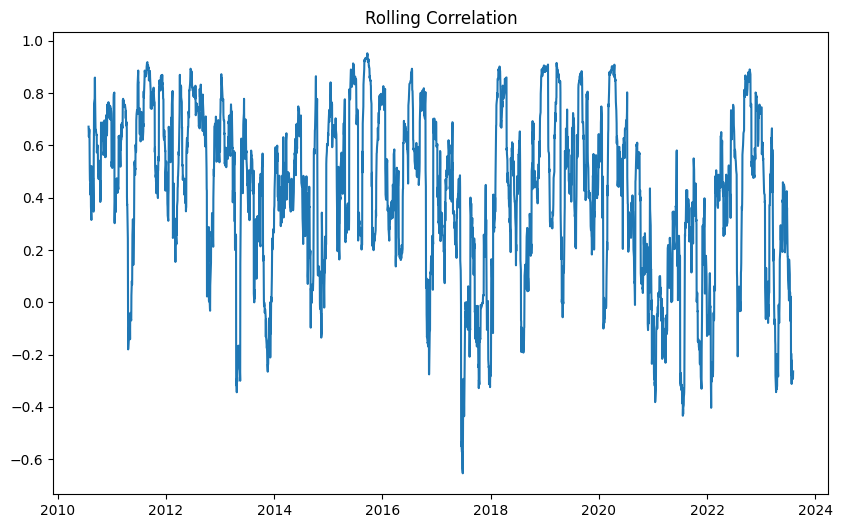

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(rolling_corr_ibm_msft)
plt.title('Rolling Correlation')
plt.show()

Interpretation

If correlation changes significantly → unstable relationship.

---

# 1️⃣8️⃣ Detecting Noisy Features

Noisy features:

* Low variance
* Weak correlation
* Small PCA contribution

---

### Variance Threshold

In [42]:
variance = log_returns.var()
selected_features = variance[variance > 0.0005].index

filtered_log_returns = log_returns[selected_features]

In [43]:
variance

,0
Ticker,
AAPL,0.000318
AMD,0.001254
AMZN,0.000430
CSCO,0.000282
GOOG,0.000295
IBM,0.000203
MSFT,0.000272
NFLX,0.001054
SBUX,0.000281



---

# 1️⃣9️⃣ PCA Noise Reduction

Remove low-impact components.

In [44]:
filtered_log_returns

Ticker,AMD,NFLX,TSLA
Date,,,
2010-06-30,-0.021622,-0.035532,-0.002515
2010-07-01,0.009517,0.009253,-0.081723
2010-07-02,-0.030222,-0.023808,-0.134312
2010-07-06,-0.018298,0.001773,-0.175470
2010-07-07,0.048520,0.099480,-0.019431
...,...,...,...
2023-07-28,0.016603,0.030064,0.041105
2023-07-31,0.012667,0.030508,0.003709
2023-08-01,0.027588,-0.000798,-0.024069


In [47]:
pca = PCA(n_components=3)

x_pca = pca.fit_transform(filtered_log_returns)

In [48]:
x_pca

array([[-0.03355202, -0.0140653 , -0.02305815],
       [-0.04373001,  0.06486002,  0.03094706],
       [-0.1170418 ,  0.07265579,  0.03253816],
       ...,
       [-0.0008047 ,  0.03697994, -0.00269259],
       [-0.07323296, -0.03284406,  0.01580663],
       [ 0.04241767,  0.02084042, -0.00156454]])



This removes noise while preserving major market signals.

---

# 📊 Final Insights

1. Stock returns behave as **random variables**
2. Financial returns are **heavy-tailed**
3. Normal distribution assumptions often fail
4. Asset relationships can be represented using **covariance matrices**
5. Eigenvalues reveal **dominant market risk factors**
6. PCA extracts hidden financial drivers
7. Asset correlations change over time
8. Stable features are crucial for modeling
9. PCA helps remove noisy signals

---

